In [2]:
import gfapy
import networkx as nx
import numpy as np
from itertools import product, combinations
from dimod import BQM
from dwave.system import LeapHybridSampler
from math import floor
import re
import matplotlib.pyplot as plt

In [7]:
def oriented_graph_from_file(filename):
    """Reads a .gfa file into an oriented graph.

    Args:
        filename (str): filepath to read.

    Returns:
        nx.Graph: corresponding oriented graph.
    """
    gfa = gfapy.Gfa.from_file(filename, vlevel=0)
    graph = nx.DiGraph()
    for segment_line in gfa.segments:
        graph.add_node(f'{segment_line.name}_+', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
        graph.add_node(f'{segment_line.name}_-', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
    for edge_line in gfa.edges:
        v1 = edge_line.sid1
        v2 = edge_line.sid2
        graph.add_edges_from([
            (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
        ])
        v1.invert()
        v2.invert()
        graph.add_edges_from([
            (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
        ])
    return graph

In [8]:
def normalise_node_weights(graph, normalisation):
    for node in graph.nodes:
        graph.nodes[node]["weight"] = round(graph.nodes[node]["weight"] / normalisation)
    return graph

In [9]:
def sample_array_to_paths(sample_array: np.ndarray, nodes: list, V: int):
    nz = np.nonzero(sample_array == 1)
    path_list_concat = [
        (
            nz[0][i],
            nz[1][i], 
            nodes[nz[2][i] * 2 + nz[3][i]] if nz[2][i] in range(V) else 'end'
        ) for i in range(nz[0].shape[0])
    ]
    two_path_list = [path_list_concat[0:int(len(path_list_concat)/2)], path_list_concat[int(len(path_list_concat)/2):len(path_list_concat)]]
    return two_path_list

def get_original_vertex_name(vertex_name):
    pattern = r'(.+)_([\+\-])+'
    match = re.search(pattern, vertex_name)
    if match is None:
        raise Exception('Could not retrieve vertex name')
    else:
        return match.group(1)

def validate_path(paths: list, graph: nx.Graph):
    """Checks the constraints for a path on a graph.
    
    In particular:
     - does the path go along graph edges at each time step
     - is each node visited the correct number of times
     - is exactly one node visited per time step

    Args:
        path (list): _description_
        graph (nx.Graph): _description_
    """
    for idx, path in enumerate(paths):
        time_offset = 0
        i = 0
        while i < len(path):
            if i + time_offset == path[i][1]:
                i += 1
                continue
            if path[i][0] < i + time_offset:
                print(f'Extra {"x" if idx == 0 else "y"} node at time {path[i][1]}')
                time_offset -= 1
                i += 1
                continue
            if path[i][0] > i + time_offset:
                print(f'Skipped {"x" if idx == 0 else "y"} at time {path[i][1]}')
                time_offset += 1
                i += 1
                continue
    
    node_dict = {node: 0 for node in graph.nodes}
    node_dict['end'] = 0
    
    for idx, path in enumerate(paths):
        for x in range(len(path) - 1):
            v1 = path[x][2]
            node_dict[v1] += 1
            v2 = path[x + 1][2]
            if v1 == 'end' and not v2 == 'end':
                print(f'Left the end node at {"x" if idx == 0 else "y"} path entry {x}')
            elif (not v1 == 'end') and (not v2 == 'end') and (not (v1, v2) in graph.edges):
                print(f'Broke graph edge at {"x" if idx == 0 else "y"} path entry {x}')
        node_dict[v2] += 1
    
    nodes = list(graph.nodes)
    for i in range(int(len(nodes) / 2)):
        visits = node_dict[nodes[2 * i]] + node_dict[nodes[2 * i + 1]]
        missing_visits = graph.nodes[nodes[2 * i]]["weight"] - visits
        if  missing_visits != 0:
            print(f'Did not meet node weight for node: {get_original_vertex_name(nodes[2 * i])}. Missing visits: {missing_visits}')


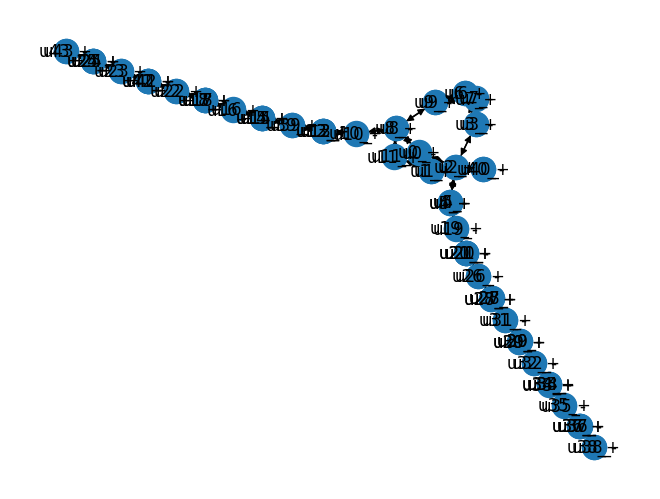

In [10]:
# g = oriented_graph_from_file('../../data/test.gfa')
# g = oriented_graph_from_file('../../data/ddDapMeze1.MT.k501.utg.final.gfa')
# g = normalise_node_weights(g, 100)
g = oriented_graph_from_file('../../data/both2.syncasm1001.utg.final.gfa')
# g = oriented_graph_from_file('../../data/both.syncasm.utg.final.gfa')
g = normalise_node_weights(g, 32)
nx.draw_kamada_kawai(g, with_labels=True)

In [11]:
nodes = list(g.nodes)
N = int(len(nodes) / 2)
total_weight = int(sum(dict(g.nodes.data('weight')).values()) / 2)
alpha = 1.2
T = int(total_weight / 2 * alpha)

lambda_t = 6
lambda_g = 6
lambda_w = 1 

In [88]:
X = [x[0] for x in product([0, 1], [0, 1])]
Y = [x[1] for x in product([0, 1], [0, 1])]
A = np.arange(12).reshape((3, 4))
A[[0, 1], :][:, [0, 1]]

array([[0, 1],
       [4, 5]])

In [72]:
# Set start nodes
start_nodes= set()
for node, val in dict(g.nodes.data('start')).items():
    if val == 'start':
        node_index_in_qubo = floor(nodes.index(node)/ 2)
        start_nodes.add(node_index_in_qubo)
Q_start_prime = np.ones((len(start_nodes), 2, len(start_nodes), 2))
for i, sigma in product(range(len(start_nodes)), range(2)):
    Q_start_prime[i, sigma, i, sigma] -= 2
Q_start_prime *= lambda_g

for X in range(2):
    Q[X, 0, list(start_nodes), :, X, 0, list(start_nodes), :] = Q_start_prime

IndexError: too many indices for array: array is 2-dimensional, but 8 were indexed

In [46]:
Q = np.zeros((2, T, N + 1, 2, 2, T, N + 1, 2), dtype=np.int8)

Q_walk_prime = np.ones((N+1, 2, N+1, 2), dtype=np.int8)
for i, sigma in product(range(N), range(2)):
    Q_walk_prime[i, sigma, i, sigma] = -1
    Q_walk_prime[N, 1, :, :] = 0
    Q_walk_prime[:, :, N, 1] = 0
    Q_walk_prime[N, 0, N, 0] = -1
Q_walk_prime *= lambda_t

for X, t in product(range(2), range(T)):
    Q[X, t, :, :, X, t, :, :] += Q_walk_prime
    

Q_graph_prime = np.zeros((N+1, 2, N+1, 2), dtype=np.int8)
Q_graph_prime[N, 0, 0:N, :] = 1

# Set u3 as end node
Q_graph_prime[0:N, :, N, 0] = 1
Q_graph_prime[3, :, N, 0] = 0
# Otherwise delete both above lines

for i, sigma, j, tau in product(range(N), range(2), range(N), range(2)):
    if not (nodes[2 * i + sigma], nodes[2 * j + tau]) in g.edges:
        Q_graph_prime[i, sigma, j, tau] = 1 
Q_graph_prime *= int(0.5 * lambda_g)

for X, t in product(range(2), range(T - 1)):
    Q[X, t, :, :, X, t + 1, :, :] += Q_graph_prime
    Q[X, t + 1, :, :, X, t, :, :] += Q_graph_prime.reshape(2*(N+1),2*(N+1)).T.reshape(N+1,2,N+1,2)
    
# Set 33 as start node 
# TODO; use a strictly positive version of this
for X, sigma in product(range(2), range(2)):
    Q[X, 0, 33, sigma, X, 0, 33, sigma] -= 1
    

for i in range(N):
    Q_weight_prime = np.ones((2, T, 2, 2, T, 2), dtype=np.int8)
    for X, t, sigma in product(range(2), range(T), range(2)):
        Q_weight_prime[X, t, sigma, X, t, sigma] -= int(2 * g.nodes[nodes[2 * i]]["weight"])

    Q[:, :, i, :, :, :, i, :] += Q_weight_prime * lambda_w
    
    
Q = Q.reshape((2 * T * (N+1) * 2), (2 * T * (N+1) * 2))

# Delete excess rows and columns
indices = np.array([(2 * (N + 1)) * (x+1) - 1 for x in range(2 * T)])
Q = np.delete(Q, indices, 0)
Q = np.delete(Q, indices, 1)

In [47]:
offset = lambda_t * T * 2  + lambda_w * int(sum(g.nodes[nodes[2 * i]]["weight"] ** 2 for i in range(N))) + 1

In [48]:
# Write to MQLib Format
filepath = f'../../out/diploid/mqlib_input_both.syncasm.txt'
ut_qubo_matrix = np.triu(Q)
non_zero = np.nonzero(ut_qubo_matrix)
non_zero_count = int(non_zero[0].shape[0])
f = open(filepath, 'w')
f.write(f'{Q.shape[0]} {non_zero_count}\n')
to_write = ''
for i in range(len(non_zero[0])):
    to_write += f'{non_zero[0][i] + 1} {non_zero[1][i] + 1} {-Q[non_zero[0][i], non_zero[1][i]]} \n'
    if i % 500 == 0:
        f.write(to_write)
        to_write = ''

f.write(to_write)
f.close()


# Haploid data:
# Solves in under 2s for up to k=81
# Solves in 5s for k=71
# Solves in 10s for k=61
# Diploid data:
# Solves well in 10-60s for simpler version
# Solves ok in 60s for harder version -> trying stronger walk/graph penalties


In [49]:

with open('../../out/diploid/mqlib_output_60s_both.syncasm.txt') as file:
    out = file.read()
    
out_data = [x for x in out.split('\n') if len(x) > 0]
solution = out_data[2].split()
solution = np.array([int(x) for x in solution])
solution_copy = np.copy(solution)

solution_energy = int(out_data[0].split(',')[3])
energy = offset - solution_energy

for X in range(2):
    for t in range(T):
        solution_copy = np.insert(solution_copy, [X * T * (N + 1) * 2 + 2 * t * (N + 1) + N * 2 + 1], 0)
solution_copy = solution_copy.reshape((2, T, N + 1, 2))


paths = sample_array_to_paths(solution_copy, nodes, N)

for path in paths:
    print(path)
    
validate_path(paths, g)

[(0, 0, 'u33_-'), (0, 1, 'u4_-'), (0, 2, 'u5_+'), (0, 3, 'u7_+'), (0, 4, 'u0_+'), (0, 5, 'u34_+'), (0, 6, 'u1_+'), (0, 7, 'u37_-'), (0, 8, 'u36_+'), (0, 9, 'u42_-'), (0, 10, 'u41_+'), (0, 11, 'u67_+'), (0, 12, 'u3_+'), (0, 13, 'end'), (0, 14, 'end'), (0, 15, 'end'), (0, 16, 'end'), (0, 17, 'end'), (0, 18, 'end'), (0, 19, 'end'), (0, 20, 'end'), (0, 21, 'end'), (0, 22, 'end'), (0, 23, 'end'), (0, 24, 'end'), (0, 25, 'end'), (0, 26, 'end'), (0, 27, 'end'), (0, 28, 'end'), (0, 29, 'end'), (0, 30, 'end'), (0, 31, 'end'), (0, 32, 'end'), (0, 33, 'end'), (0, 34, 'end'), (0, 35, 'end'), (0, 36, 'end'), (0, 37, 'end'), (0, 38, 'end'), (0, 39, 'end'), (0, 40, 'end'), (0, 41, 'end'), (0, 42, 'end'), (0, 43, 'end'), (0, 44, 'end'), (0, 45, 'end'), (0, 46, 'u2_-'), (0, 47, 'u47_+'), (0, 48, 'u49_+'), (0, 49, 'u54_-'), (0, 50, 'u52_-'), (0, 51, 'u51_+'), (0, 52, 'u73_-'), (0, 53, 'u56_+'), (0, 54, 'u59_+'), (0, 55, 'u12_-'), (0, 56, 'u11_+'), (0, 57, 'u14_+'), (0, 58, 'u64_-'), (0, 59, 'u63_-'), (0

In [ ]:
bqm = BQM(Q, 'BINARY')
bqm.offset = offset
bqm.offset

print(bqm.num_variables)
print(bqm.num_interactions)
print(max(bqm.degrees().values()))
print(np.max(Q))
print(np.min(Q))

# Num interactions = 6N + 4T - outdeg(i)
print(6 * N + 4 * T - 3)
print(np.argmax(bqm.degrees(array=True)))
print(np.unravel_index(np.argmax(bqm.degrees(array=True)), (2, T, (N+1), 2)))

In [166]:
hybrid_sampler = LeapHybridSampler()
hybrid_sampleset = hybrid_sampler.sample(bqm, label="Diploid Tangle Testing", time_limit=60)

In [152]:
hybrid_sample = hybrid_sampleset.first.sample
hybrid_energy = hybrid_sampleset.first.energy
hybrid_sample_list = np.array(list(hybrid_sample.values()))
hybrid_sample_list_copy = np.copy(hybrid_sample_list)
for X in range(2):
    for t in range(T):
        hybrid_sample_list_copy = np.insert(hybrid_sample_list_copy, [X * T * (N + 1) * 2 + 2 * t * (N + 1) + N * 2 + 1], 0)
hybrid_sample_array = hybrid_sample_list_copy.reshape((2, T, N + 1, 2))

In [34]:
# fig = plt.figure()
# ax = fig.add_subplot(111)
# ax.spy(Q)
# plt.show()

In [33]:
# # Axes: x/y, t, i, orientation
# Q = np.zeros((2, T, N + 1, 2, 2, T, N + 1, 2))

# for X in range(2):
#     for t in range(T):
#         Q[X, t, N, 0, X, t, N, 0] -= lambda_t
#         for i, sigma in product(range(N), range(2)):
#             Q[X, t, i, sigma, X, t, i, sigma] -= lambda_t
#             Q[X, t, i, sigma, X, t, N, 0] += 2 * lambda_t
#             for j, tau in product(range(N), range(2)):
#                 if not (i == j and sigma == tau):
#                     Q[X, t, i, sigma, X, t, j, tau] += lambda_t
                    

# for i, sigma in product(range(N), range(2)):
#     for X, t in product(range(2),range(T-1)):
#         Q[X, t, N, 0, X, t+1, i, sigma] += lambda_g
#     for j, tau in product(range(N), range(2)):
#         if not (nodes[2 * i + sigma], nodes[2 * j + tau]) in g.edges:
#             for X, t in product(range(2),range(T-1)):
#                 Q[X, t, i, sigma, X, t+1, j, tau] += lambda_g
                
                
# for i in range(N):
#     for t, sigma in product(range(T), range(2)):
#         for X in range(2):
#             Q[X, t, i, sigma, X, t, i, sigma] += lambda_w * (1 - 2 * g.nodes[nodes[2 * i]]["weight"])
#         for tt, tau in product(range(T), range(2)):
#             if not (tt == t and tau == sigma):
#                 for X in range(2):
#                     Q[X, t, i, sigma, X, tt, i, tau] += lambda_w
#             Q[0, t, i, sigma, 1, tt, i, tau] += 2 * lambda_w
         

# Q = Q.reshape((2 * T * (N+1) * 2), (2 * T * (N+1) * 2))
# Q = 0.5 * (Q + Q.T)

# # Delete excess rows and columns
# Q = np.delete(Q, [np.ravel_multi_index((X, t, N, 1), dims=(2, T, N+1, 2)) for t in range(T) for X in range(2)], 0)
# Q = np.delete(Q, [np.ravel_multi_index((X, t, N, 1), dims=(2, T, N+1, 2)) for t in range(T) for X in range(2)], 1)
                

In [39]:
Q = np.zeros((2, T, N + 1, 2, 2, T, N + 1, 2), dtype=np.int8)

start_nodes= set()
for node, val in dict(g.nodes.data('start')).items():
    if val == 'start':
        node_index_in_qubo = floor(list(g.nodes).index(node)/ 2)
        start_nodes.add(node_index_in_qubo)

start_nodes = list(start_nodes)
if len(start_nodes) > 0:
    print(f'Setting start node: {start_nodes[0]}')
    Q_start_prime = np.ones((2, 2), dtype=np.int8)
    for sigma in range(2):
        Q_start_prime[sigma, sigma] = -1
    Q_start_prime *= 10    
    
    for X in range(2):
        Q[X, 0, start_nodes[0], :, X, 0, start_nodes[0], :] += Q_start_prime

Q = Q.reshape((2 * T * (N+1) * 2), (2 * T * (N+1) * 2))

# Delete rows and columns corresponding to the extra end node we do not need
indices = np.array([(2 * (N + 1)) * (x+1) - 1 for x in range(2 * T)])
Q = np.delete(Q, indices, 0)
Q = np.delete(Q, indices, 1)
print(np.nonzero(Q))
sol = np.array([0] * 86 + [1] + [0] * (4 * (N+1) * T - 87 ))
sol = np.delete(sol, indices)
print('Start energy')
print(sol @ Q @ sol)

Setting start node: 43
(array([  86,   86,   87,   87, 4091, 4091, 4092, 4092]), array([  86,   87,   86,   87, 4091, 4092, 4091, 4092]))
Start energy
-10
